In [4]:
# Clear all variables
%reset -f

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import StandardScaler
import math
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm
from torch.distributions import Normal
import nnwosd as wosd
import importlib
importlib.reload(wosd)
import pickle
from pysfa import SFA
import pandas as pd

# -------------------------------
# Set random seed for reproducibility
# -------------------------------
seed = 11234
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
np.random.seed(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
# -------------------------------



with open('rice92_data.pkl', 'rb') as f:
    loaded_dict = pickle.load(f)

# loaded_dict

x1= torch.tensor(np.log(np.array(loaded_dict['AREA']))).reshape(-1,1)
x2= torch.tensor(np.log(np.array(loaded_dict['LABOR']))).reshape(-1,1)
x3= torch.tensor(np.log(np.array(loaded_dict['NPK']))).reshape(-1,1)
x_tensor = torch.cat((x1,x2,x3), dim=1)
y = torch.tensor(np.log(np.array(loaded_dict['PROD']))).reshape(-1,1)

# 2. Standardize input and output data
scaler_X = StandardScaler()
scaler_y = StandardScaler()

# Fit scalers on the data and transform
X_standardized = torch.tensor(scaler_X.fit_transform(x_tensor), dtype=torch.float32)
y_standardized = torch.tensor(scaler_y.fit_transform(y), dtype=torch.float32)

# Instantiate the model
input_size = 3  # Number of input features
hidden_sizes = [32,16]  # Hidden layer sizes
output_size = 1 # 

# activation_fun = nn.ELU()
activation_fun = wosd.FlippedLeakRELU(alpha=0.01)
model = wosd.MLP(input_size,hidden_sizes,output_size,activation_func=activation_fun)

#initial values
sigma_v_sfm = 0.188
sigma_u_sfm = 0.13

# Instantiate the NLL loss function
nll_loss = wosd.GaussianNLLLoss(sigma_v=sigma_v_sfm,sigma_u=sigma_u_sfm)

# 5. Set up the optimizer (Adam)
optimizer = optim.Adam(list(model.parameters()) + [nll_loss.log_std_v, nll_loss.log_std_u] , lr=0.01)


# Variables to track the best loss and model parameters
best_loss = float('inf')  # Initialize best loss to infinity
best_model_state = None    # To save the model state

# List to store loss values for plotting
loss_values = []

# Train the deep learning model by minimizing the NLL loss
epochs = 1000
for epoch in range(epochs):
    model.train()  # Set the model to training mode

    # Forward pass: Predict outputs
    y_pred = model(X_standardized)

    # Compute NLL loss
    loss = nll_loss(y_pred, y_standardized)

    # Backward pass and optimization step
    optimizer.zero_grad()  # Zero the gradients
    loss.backward()  # Compute gradients
    optimizer.step()  # Update model parameters

    # Track loss values for plotting
    loss_values.append(loss.item())
    
    with torch.no_grad():  # Turn off gradients temporarily
        for layer in model.layers:
            layer.weight.data.clamp_(min=0)  # Clamp weights to be >= 0
        model.output.weight.clamp_(min=0)  # Set min to 0 to make all weights >= 0
        
    # Check if the current loss is the best loss
    if loss.item() < best_loss:
        best_loss = loss.item()  # Update the best loss
        best_model_state = model.state_dict()  # Save the model state

    # Print progress every 50 epochs
    if (epoch + 1) % 50 == 0:
        print(f'Epoch [{epoch + 1}/{epochs}], Loss: {loss.item():.4f}, '
              f'Log-Std(V): {nll_loss.log_std_v.item():.4f}, '
              f'Log-Std(U): {nll_loss.log_std_u.item():.4f}')

# After training, load the best model parameters
model.load_state_dict(best_model_state)

# Make predictions using the best model
with torch.no_grad():
    std_v_est = torch.exp(nll_loss.log_std_v).item()
    std_u_est = torch.exp(nll_loss.log_std_v).item()
    
    y_pred_best = model(X_standardized) + np.sqrt(2/np.pi)*std_u_est
    
    # Inverse transform predictions to original scale
    y_pred_best_original = scaler_y.inverse_transform(y_pred_best.numpy())

ModuleNotFoundError: No module named 'torch'

In [20]:
sigma_v_nn,sigma_u_nn=torch.exp(nll_loss.log_std_v).item()*scaler_y.scale_,torch.exp(nll_loss.log_std_u).item()*scaler_y.scale_

In [21]:
sigma_v_nn,sigma_u_nn

(array([0.15393284]), array([0.10644292]))

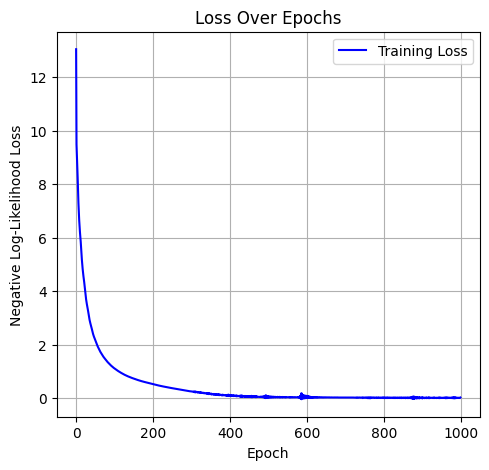

In [22]:
# 2. Plotting the loss 
# Plotting the loss over epochs
plt.figure(figsize=(12, 5))

# Subplot for loss
plt.subplot(1, 2, 1)
plt.plot(loss_values, label='Training Loss', color='blue')
plt.title('Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Negative Log-Likelihood Loss')
plt.grid()
plt.legend()

In [23]:
#TE
vectorized_TE_fun = np.vectorize(wosd.TE_fun)
TE_nn = vectorized_TE_fun(residuals=(y.numpy()-y_pred_best_original),sig_v=sigma_v_nn,sig_u=sigma_u_nn).reshape(-1)

sorted_indices = np.argsort(TE_nn)

In [24]:
pd.DataFrame({
    "Index": loaded_dict.index[sorted_indices][-5:][::-1],
    "TE": TE_nn[sorted_indices][-5:][::-1]
})

,Index,TE
0,90,0.960737
1,117,0.946690
2,123,0.944094
3,118,0.941632
4,127,0.940415


In [25]:
pd.DataFrame({
    "Index": loaded_dict.index[sorted_indices][:5],
    "TE": TE_nn[sorted_indices][:5]
})

,Index,TE
0,97,0.838431
1,94,0.843189
2,126,0.847808
3,120,0.851199
4,129,0.863478
